# Chest X-ray condition detection (NIH ChestX-ray14)

This notebook trains a model to spot 14 different chest conditions from a single chest X-ray. It uses
the public NIH ChestX-ray14 dataset: about 112,000 X-rays from roughly 30,000 patients, where each
image can have more than one condition at the same time. That makes it a multi-label problem (any
combination of the 14), not a pick-one problem.

Everything runs from this one notebook. When you run all the cells it installs the libraries it needs,
downloads the data, trains and compares a bunch of models, tunes the best one, explains its
predictions, saves the model, and writes a small web app you can use to test X-rays yourself.

## What happens, in order

0. Setup: install libraries and download the data.
1. Look at the data: a sample of the X-rays and labels, how common each condition is, and why plain accuracy is a bad way to score this.
2. Turn each image into numbers using a pretrained network (transfer learning), with a quick PCA look.
3. Try a bunch of models and compare them, including train vs. test accuracy.
4. Take the best model and pick a sensible cutoff for each condition.
5. Check where it works and where it fails (per-condition scores and a confusion matrix).
5b. Two extra tests: does the train/test split matter, and would more data help?
6. Explain a prediction with a Grad-CAM heat map (a right one and a wrong one), and save the model.
6b. Deep learning that needs a GPU: a CNN from scratch and fine-tuning (skipped automatically on a CPU).
7. Build the web app.
8. What we tried and what we learned, and how it compares to the state of the art.

## Where each project requirement is answered

- The problem, and a sample of the data: section 1
- Some interesting findings in the data (EDA): section 1, plus the PCA view in section 2
- The current state of the art: section 8
- What we tried, what worked, and what didn't: sections 3, 4, and 8
- Accuracy on both train and test, and a confusion matrix: sections 3 and 5
- A positive and a negative example (good for a live demo): section 6, and the app in section 7

## A note on scoring (this part matters)

Most X-rays are negative for most conditions, so a model that just says "nothing's wrong" every single
time is still right about 95% of the time. That makes plain accuracy almost useless here. So instead we
mostly look at:

- AUC (area under the ROC curve): how well the model ranks sick vs. healthy. It doesn't depend on where
  you set the yes/no cutoff, so it's hard to fake. This is the number we trust the most.
- Recall (sensitivity): of the X-rays that really have a condition, how many did we catch. In anything
  medical this usually matters more than precision, because a missed case is worse than a false alarm.
- Accuracy is still shown, but only next to AUC, never on its own.

## Running it

All the outputs are already saved in this notebook, so you can read it top to bottom without running
anything. If you do want to run it yourself, the easiest way is Google Colab: go to
colab.research.google.com, upload this notebook, turn on a GPU under Runtime > Change runtime type
(it's much faster), then click Runtime > Run all. Locally (Jupyter or VS Code) just run all the cells
and the first one installs anything that's missing.

A heads-up on size and time: the labels file is small (about 8 MB) but the images are around 9 GB in
total, and on a plain CPU the whole thing takes the better part of an hour. So if you re-run it, do it
on Colab with a GPU. If you just want a quick look, set the environment variable CXR_SAMPLE_SIZE to
something like 1000 (and CXR_N_ARCHIVES to 1) first, which keeps the download and run small.

This is a class project for learning, not a real medical tool, so please don't use it to diagnose anyone.


## 0. Setup: install libraries and download the data

First we install the libraries and then download the data into a local `cxr_data/` folder: the small
labels file (a CSV) and the image archives. Anything that's already been downloaded is skipped, so it's
cheap to run this more than once.

**Before you start:** the easiest way to run this is **Google Colab** (free, nothing to install). If you
run it on your own computer instead, use **Python 3.10 to 3.12**, TensorFlow doesn't support newer
versions yet. The cell right below checks this for you.


In [1]:
# Environment check. TensorFlow only supports Python 3.9-3.12, so warn early if the Python is too new.
import sys
v = sys.version_info
if v >= (3, 13):
    print(f"WARNING: you are on Python {v.major}.{v.minor}, but TensorFlow needs Python 3.9-3.12.")
    print("The install step below will likely fail on this Python.")
    print("Easiest fix: run this notebook in Google Colab (it's already on a supported Python):")
    print("  https://colab.research.google.com  ->  Upload notebook  ->  Runtime  ->  Run all")
else:
    print(f"Python {v.major}.{v.minor} detected - good to go.")

Python 3.12 detected - good to go.


In [2]:
# Install dependencies. Quiet so the output stays clean; safe to re-run.
import subprocess
pkgs = ["tensorflow", "pillow", "scikit-learn", "scipy", "pandas", "matplotlib", "streamlit"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
print("Dependencies ready.")

Dependencies ready.


In [3]:
# Imports, configuration, and the public data URLs.
import os, io, time, json, tarfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (roc_auc_score, f1_score, fbeta_score, hamming_loss,
                             precision_score, recall_score, confusion_matrix)

# ---- Configuration (override via environment variables, no code edit needed) ----
IMG_SIZE     = (224, 224)
NUM_CLASSES  = 14
RANDOM_STATE = 42
N_ARCHIVES   = int(os.environ.get("CXR_N_ARCHIVES", 3))      # ~2 GB each
_ss          = os.environ.get("CXR_SAMPLE_SIZE", "")         # blank = use ALL downloaded images
SAMPLE_SIZE  = int(_ss) if _ss.strip() else None

DATA_DIR = os.path.abspath("cxr_data")   # downloads/cache
APP_DIR  = os.path.abspath("cxr_app")    # saved model + generated app
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(APP_DIR, exist_ok=True)

CLASSES = ["Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
           "Mass", "Nodule", "Pneumonia", "Pneumothorax",
           "Consolidation", "Edema", "Emphysema", "Fibrosis",
           "Pleural_Thickening", "Hernia"]

# Public label file (HuggingFace mirror), small CSV, ~8 MB.
LABEL_URL = ("https://huggingface.co/datasets/alkzar90/NIH-Chest-X-ray-dataset/"
             "resolve/main/data/Data_Entry_2017_v2020.csv")
LABEL_CSV = os.path.join(DATA_DIR, "Data_Entry_2017_v2020.csv")

# Public image archives (official NIH Box), each ~2 GB, ~4,800 PNGs.
ARCHIVE_URLS = [
    "https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz",  # images_001
    "https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz",  # images_002
    "https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz",  # images_003
]

print("TensorFlow", tf.__version__)
print(f"Archives: {N_ARCHIVES}  |  Image cap: {SAMPLE_SIZE or 'ALL downloaded'}")
print(f"Data: {DATA_DIR}\nApp:  {APP_DIR}")

TensorFlow 2.20.0
Archives: 3  |  Image cap: ALL downloaded
Data: /content/cxr_data
App:  /content/cxr_app


## Try it now: classify an X-ray (no training needed)

You do **not** have to train anything to see the model work. After running the three setup cells above
(the Python check, the install, and the imports/configuration cell), just run the cells in this section.
They download the already-trained model (about 20 MB, one time) from the project's GitHub repo and let
you classify chest X-rays right here in the notebook, with the Grad-CAM heat map.

You can **skip the big data download and all the training sections below** unless you actually want to
retrain the model yourself. This is the section to use for a quick demo on any machine (it works in
Google Colab with nothing to install).

In [ ]:
# Load the already-trained model. Downloads it once if it isn't here yet. NO training required.
MODEL_REPO = "https://raw.githubusercontent.com/SpencerGoss/chest-xray-classifier/main/cxr_app"

def _grab(rel, min_bytes=100):
    dest = os.path.join(APP_DIR, *rel.split("/"))
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    if not (os.path.exists(dest) and os.path.getsize(dest) > min_bytes):
        urllib.request.urlretrieve(f"{MODEL_REPO}/{rel}", dest)
    return dest

_grab("cxr14_model.keras", min_bytes=1_000_000)
_grab("thresholds.json"); _grab("sample_labels.json")
demo_model = keras.models.load_model(os.path.join(APP_DIR, "cxr14_model.keras"))
DEMO_TH = np.array(json.load(open(os.path.join(APP_DIR, "thresholds.json"))))
SAMPLE_LABELS = json.load(open(os.path.join(APP_DIR, "sample_labels.json")))
SAMPLE_NAMES = list(SAMPLE_LABELS.keys())
for nm in SAMPLE_NAMES:
    _grab(f"samples/{nm}")
print("Trained model loaded. Ready to classify, no training needed.")
print(f"{len(SAMPLE_NAMES)} sample X-rays are available to try.")

In [ ]:
from scipy.ndimage import zoom

def classify_xray(image_path, show=True):
    # Run the trained model on one X-ray: print per-condition probabilities, the conditions it
    # flags (using the tuned per-condition thresholds), and a Grad-CAM heat map.
    img = Image.open(image_path).convert("RGB").resize(IMG_SIZE)
    arr = np.asarray(img, np.float32)            # raw 0-255 pixels, matching how it was trained
    conv, preds = demo_model(arr[None])
    probs = preds[0].numpy()
    order = np.argsort(probs)[::-1]
    print("Predicted conditions  (probability | flagged at its tuned threshold):")
    for i in order:
        flag = "   <-- FLAGGED" if probs[i] >= DEMO_TH[i] else ""
        print(f"  {CLASSES[i]:20s} {probs[i]:.3f}{flag}")
    truth = SAMPLE_LABELS.get(os.path.basename(image_path))
    if truth:
        print(f"\nGround truth for this sample: {truth}")
    if show:
        top = int(order[0])
        with tf.GradientTape() as tape:
            conv_out, p = demo_model(arr[None]); loss = p[:, top]
        grads = tape.gradient(loss, conv_out)
        w = tf.reduce_mean(grads, axis=(0, 1, 2))
        cam = tf.reduce_sum(conv_out[0] * w, axis=-1)
        cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
        cam = zoom(cam.numpy(), (IMG_SIZE[0] / cam.shape[0], IMG_SIZE[1] / cam.shape[1]), order=1)
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(img); ax[0].set_title("X-ray"); ax[0].axis("off")
        ax[1].imshow(img); ax[1].imshow(cam, cmap="jet", alpha=0.4)
        ax[1].set_title("Grad-CAM: " + CLASSES[top]); ax[1].axis("off")
        plt.show()

# Classify one of the bundled sample X-rays. Change the index (0 to N-1) to try a different one,
# or call classify_xray("your_image.png") on your own file.
classify_xray(os.path.join(APP_DIR, "samples", SAMPLE_NAMES[0]))

In [ ]:
# OPTIONAL: classify your OWN chest X-ray. In Google Colab this opens a file picker.
try:
    from google.colab import files
    uploaded = files.upload()                    # choose a PNG/JPG chest X-ray
    for name in uploaded:
        classify_xray(name)
except ModuleNotFoundError:
    print("File upload works in Google Colab. Outside Colab, call it directly, e.g.:")
    print("   classify_xray('path/to/your_xray.png')")

In [4]:
# Download helper: streams to disk with progress, skips files already present.
def download(url, dest, min_bytes, label):
    if os.path.exists(dest) and os.path.getsize(dest) > min_bytes:
        print(f"  cached: {os.path.basename(dest)} ({os.path.getsize(dest)/1e6:.0f} MB)")
        return dest
    print(f"  downloading {label} ...")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        total, done, mark = int(r.headers.get("Content-Length", 0)), 0, 10
        while True:
            chunk = r.read(1 << 20)          # 1 MB at a time
            if not chunk:
                break
            f.write(chunk); done += len(chunk)
            if total and done * 100 // total >= mark:
                print(f"    {mark}%  ({done/1e6:.0f}/{total/1e6:.0f} MB)"); mark += 10
    print(f"  done: {os.path.basename(dest)} ({os.path.getsize(dest)/1e6:.0f} MB)")
    return dest

download(LABEL_URL, LABEL_CSV, min_bytes=1_000_000, label="label CSV (~8 MB)")

archive_paths = []
for i, url in enumerate(ARCHIVE_URLS[:N_ARCHIVES]):
    dest = os.path.join(DATA_DIR, f"images_{i+1:03d}.tar.gz")
    archive_paths.append(download(url, dest, min_bytes=1_000_000_000,
                                  label=f"image archive {i+1} (~2 GB)"))

print("Indexing images ...")
image_to_archive = {}
for path in archive_paths:
    with tarfile.open(path, "r:gz") as tar:
        for m in tar.getmembers():
            if m.name.endswith(".png"):
                image_to_archive[os.path.basename(m.name)] = path
print("Images available locally:", len(image_to_archive))

  downloading label CSV (~8 MB) ...
    10%  (1/9 MB)
    20%  (2/9 MB)
    30%  (3/9 MB)
    40%  (4/9 MB)
    50%  (5/9 MB)
    60%  (6/9 MB)
    70%  (7/9 MB)
    80%  (8/9 MB)
    90%  (9/9 MB)
  done: Data_Entry_2017_v2020.csv (9 MB)
  downloading image archive 1 (~2 GB) ...
    10%  (201/2008 MB)
    20%  (403/2008 MB)
    30%  (603/2008 MB)
    40%  (804/2008 MB)
    50%  (1005/2008 MB)
    60%  (1206/2008 MB)
    70%  (1406/2008 MB)
    80%  (1607/2008 MB)
    90%  (1808/2008 MB)
    100%  (2008/2008 MB)
  done: images_001.tar.gz (2008 MB)
  downloading image archive 2 (~2 GB) ...
    10%  (395/3953 MB)
    20%  (791/3953 MB)
    30%  (1186/3953 MB)
    40%  (1581/3953 MB)
    50%  (1977/3953 MB)
    60%  (2372/3953 MB)
    70%  (2767/3953 MB)
    80%  (3163/3953 MB)
    90%  (3558/3953 MB)
    100%  (3953/3953 MB)
  done: images_002.tar.gz (3953 MB)
  downloading image archive 3 (~2 GB) ...
    10%  (393/3929 MB)
    20%  (786/3929 MB)
    30%  (1180/3929 MB)
    40%  (1572/39

## 1. Look at the data

The labels file describes all 112,120 images. The first thing you notice is how lopsided it is: most
X-rays have no finding at all, or just one, and some conditions barely show up. The two charts below
make that obvious. This imbalance is the whole reason we can't trust plain accuracy later on, so it's
worth seeing it up front.


Total images: 112120
Unique patients: 30805

Sample rows from the labels file:
     Image Index         Finding Labels  Patient Age Patient Gender View Position
00000001_000.png           Cardiomegaly           57              M            PA
00000001_001.png Cardiomegaly|Emphysema           58              M            PA
00000001_002.png  Cardiomegaly|Effusion           58              M            PA
00000002_000.png             No Finding           80              M            PA
00000003_001.png                 Hernia           74              F            PA
00000003_002.png                 Hernia           75              F            PA
00000003_003.png    Hernia|Infiltration           76              F            PA
00000003_004.png                 Hernia           77              F            PA

No Finding: 60361 (53.8% of images)

Condition frequency (whole dataset):
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6

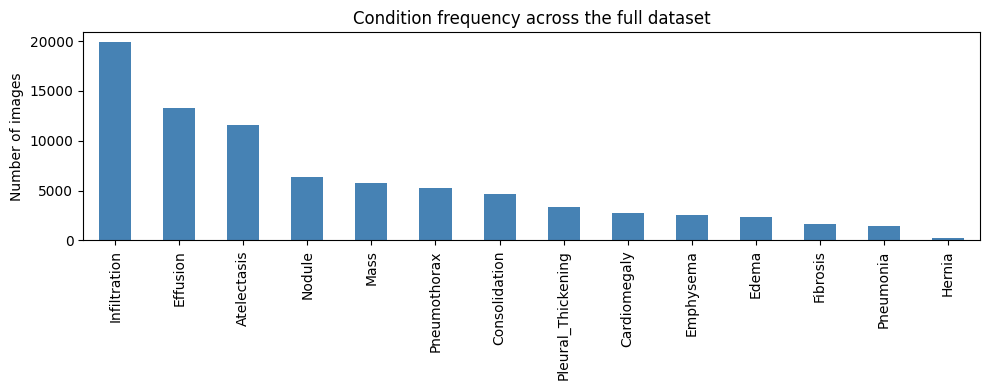

In [5]:
df = pd.read_csv(LABEL_CSV)
print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

# A sample of the labels table so you can see what the data looks like.
print("\nSample rows from the labels file:")
print(df[["Image Index", "Finding Labels", "Patient Age", "Patient Gender",
          "View Position"]].head(8).to_string(index=False))

# Multi-hot encode the 14 findings: a length-14 vector of 0/1 per image.
def encode(labels):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if pd.isna(labels) or labels == "No Finding":
        return vec
    for f in str(labels).split("|"):
        if f in CLASSES:
            vec[CLASSES.index(f)] = 1.0
    return vec

df["multi_hot"] = df["Finding Labels"].apply(encode)

counts = np.sum(np.stack(df["multi_hot"].values), axis=0).astype(int)
freq = pd.Series(counts, index=CLASSES).sort_values(ascending=False)
no_finding = int((df["Finding Labels"] == "No Finding").sum())

print(f"\nNo Finding: {no_finding} ({no_finding/len(df)*100:.1f}% of images)")
print("\nCondition frequency (whole dataset):")
print(freq.to_string())

plt.figure(figsize=(10, 4))
freq.plot(kind="bar", color="steelblue")
plt.title("Condition frequency across the full dataset")
plt.ylabel("Number of images"); plt.tight_layout(); plt.show()

Findings per image:
  0 finding(s): 60361 images (53.8%)
  1 finding(s): 30963 images (27.6%)
  2 finding(s): 14306 images (12.8%)
  3 finding(s): 4856 images (4.3%)
  4 finding(s): 1247 images (1.1%)
  5 finding(s): 301 images (0.3%)
  6 finding(s): 67 images (0.1%)
  7 finding(s): 16 images (0.0%)
  8 finding(s): 1 images (0.0%)
  9 finding(s): 2 images (0.0%)


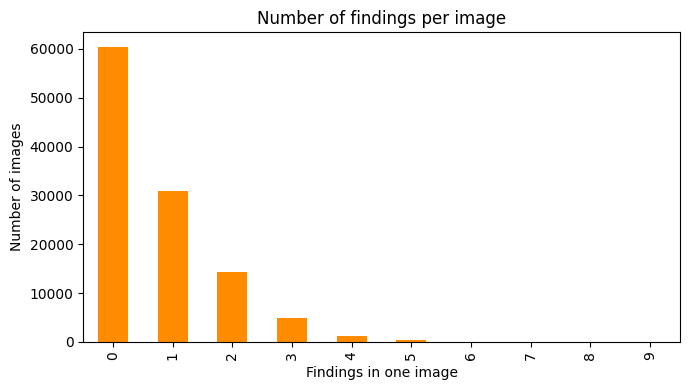


Takeaway: an average image is NEGATIVE for 13.28 of the 14 conditions.
A model that says 'no condition' for everything is right most of the time, 
which is why per-condition AUC and recall matter far more than raw accuracy.


In [6]:
n_findings = np.sum(np.stack(df["multi_hot"].values), axis=1).astype(int)
dist = pd.Series(n_findings).value_counts().sort_index()
print("Findings per image:")
for k, v in dist.items():
    print(f"  {k} finding(s): {v} images ({v/len(df)*100:.1f}%)")

plt.figure(figsize=(7, 4))
dist.plot(kind="bar", color="darkorange")
plt.title("Number of findings per image")
plt.xlabel("Findings in one image"); plt.ylabel("Number of images")
plt.tight_layout(); plt.show()

print("\nTakeaway: an average image is NEGATIVE for",
      NUM_CLASSES - round(n_findings.mean(), 2), "of the 14 conditions.")
print("A model that says 'no condition' for everything is right most of the time, ")
print("which is why per-condition AUC and recall matter far more than raw accuracy.")

### Which conditions show up together

Because an image can carry several findings at once, the conditions are not independent. The heat map
below reads as *"of all the images that have the COLUMN condition, what share also have the ROW
condition"*. Bright cells are pairs that travel together (for example Edema with Pneumonia, Effusion
with Cardiomegaly, Pneumothorax with Emphysema). This is exactly why a single-label accuracy score is
the wrong tool here: the labels overlap, so we score each condition on its own with AUC and recall.

Most common condition pairs (images sharing both):
  Effusion + Infiltration: 4000
  Atelectasis + Effusion: 3275
  Atelectasis + Infiltration: 3264
  Infiltration + Nodule: 1546
  Effusion + Consolidation: 1287


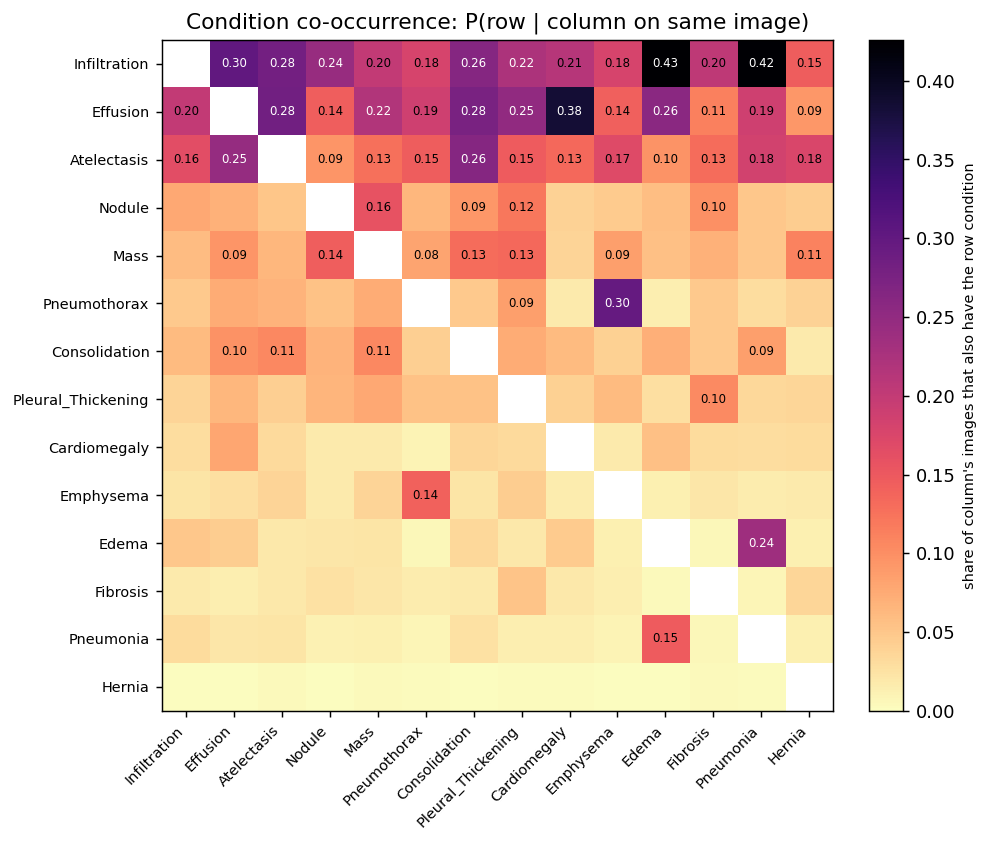

In [ ]:
# Condition co-occurrence: P(row present | column present) on the same image.
MH = np.stack(df["multi_hot"].values)                  # images x 14
co = MH.T.dot(MH).astype(float)                        # 14 x 14 co-occurrence counts
totals = np.diag(co).copy()
cond = co / totals[None, :]                            # normalise by the column's own count
np.fill_diagonal(cond, np.nan)                         # blank the diagonal (a condition with itself)

order = np.argsort(totals)[::-1]                       # most common conditions first
cond = cond[np.ix_(order, order)]
labels = [CLASSES[i] for i in order]
vmax = np.nanmax(cond)

plt.figure(figsize=(8.2, 6.6))
plt.imshow(cond, cmap="magma_r", vmin=0, vmax=vmax)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cond[i, j]
        if not np.isnan(v) and v >= 0.08:
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                     color="white" if v > vmax * 0.5 else "black")
cb = plt.colorbar(fraction=0.046, pad=0.04)
cb.set_label("share of column's images that also have the row condition", fontsize=8)
plt.title("Condition co-occurrence: P(row | column on same image)")
plt.tight_layout(); plt.show()

# Strongest pairs by raw shared-image count (a quick text summary).
raw = MH.T.dot(MH).astype(int); np.fill_diagonal(raw, 0)
pairs = sorted(((raw[i, j], CLASSES[i], CLASSES[j])
                for i in range(NUM_CLASSES) for j in range(i + 1, NUM_CLASSES)), reverse=True)
print("Most common condition pairs (images sharing both):")
for c, a, b in pairs[:5]:
    print(f"  {a} + {b}: {c}")

### Who is in the dataset

A quick look at age and sex. This matters for generalisation: a model only learns the population it was
trained on. ChestX-ray14 skews toward middle-aged adults and has somewhat more male than female scans,
so per-group performance is something a real deployment would need to watch.

Median age 49, mean 46.6. Male 56% / Female 44%.


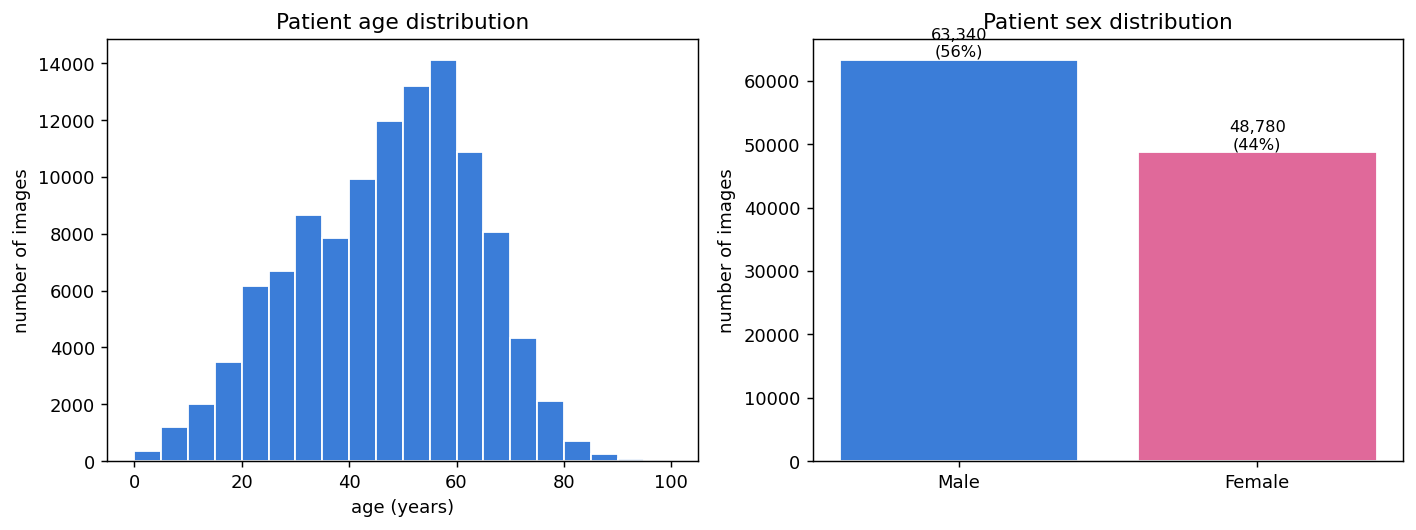

In [ ]:
age = pd.to_numeric(df["Patient Age"], errors="coerce")
age = age[(age >= 0) & (age <= 100)]                   # drop a few bogus 400+ age entries
sex = df["Patient Gender"].astype(str).str.upper().str[0]
sc = sex.value_counts().reindex(["M", "F"]).fillna(0)
tot = sc.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(age, bins=range(0, 101, 5), color="#3b7dd8", edgecolor="white")
ax[0].set_title("Patient age distribution")
ax[0].set_xlabel("age (years)"); ax[0].set_ylabel("number of images")
bars = ax[1].bar(["Male", "Female"], sc.values, color=["#3b7dd8", "#e0699a"], edgecolor="white")
ax[1].set_title("Patient sex distribution"); ax[1].set_ylabel("number of images")
for b, v in zip(bars, sc.values):
    ax[1].text(b.get_x() + b.get_width() / 2, v, f"{int(v):,}\n({v/tot*100:.0f}%)",
               ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

print(f"Median age {age.median():.0f}, mean {age.mean():.1f}. "
      f"Male {sc['M']/tot*100:.0f}% / Female {sc['F']/tot*100:.0f}%.")

## 2. Turn each image into numbers (transfer learning)

Training an image model from scratch needs a lot of data and a GPU, so instead we borrow one that's
already been trained. EfficientNetB0 was trained on ImageNet (millions of everyday photos) and already
knows how to pick out edges, shapes and textures. We freeze it (don't change its weights) and just use
it to turn each 224x224 X-ray into a list of 1,280 numbers that summarize what's in the image. Our own
models then learn from those 1,280 numbers instead of the raw pixels. That's transfer learning. By
default we use every image we downloaded; set CXR_SAMPLE_SIZE to cap it for a quick test.

Two small preparation steps come straight from the class examples. Each image goes through the
backbone's own `preprocess_input` (the scaling the network expects), and the 1,280 numbers are then
standardized with StandardScaler so they're all on a comparable scale before the neural network sees
them. We fit the scaler on the training data only, and both steps get baked into the saved model so the
app does them automatically.

We split the images three ways: 60% to train on, 20% for validation (used in Section 4 to pick cutoffs
without touching the test set), and 20% held back as a test set that we only score on at the very end.


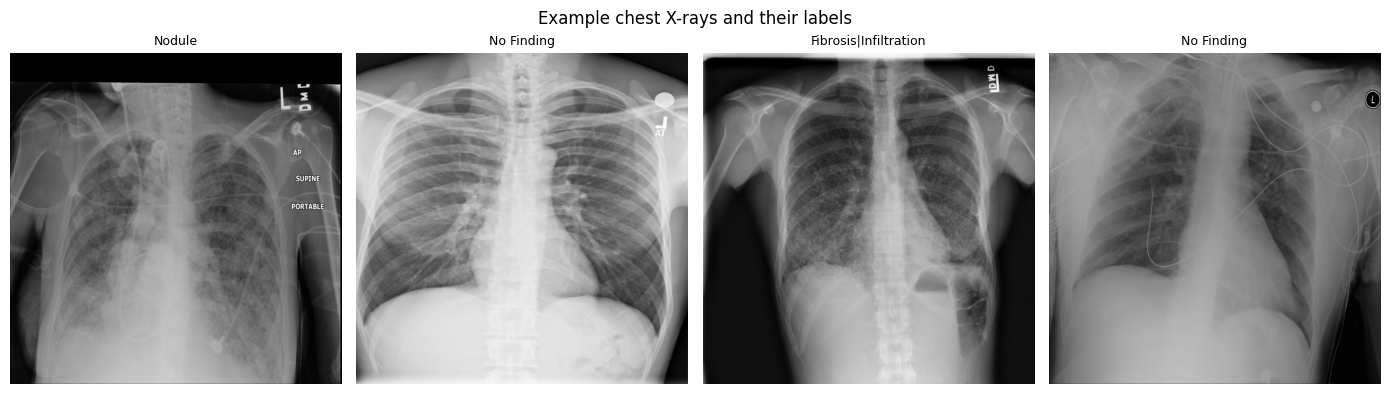

In [7]:
# Show a few real chest X-rays with their labels, so we can actually see the data.
def peek_image(name):
    with tarfile.open(image_to_archive[name], "r:gz") as tar:
        for m in tar.getmembers():
            if os.path.basename(m.name) == name:
                return Image.open(io.BytesIO(tar.extractfile(m).read())).convert("L")

examples = df[df["Image Index"].isin(image_to_archive)].sample(4, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (_, row) in zip(axes, examples.iterrows()):
    ax.imshow(peek_image(row["Image Index"]), cmap="gray")
    ax.set_title(row["Finding Labels"], fontsize=9)
    ax.axis("off")
plt.suptitle("Example chest X-rays and their labels"); plt.tight_layout(); plt.show()

In [8]:
# Use every downloaded image (or SAMPLE_SIZE if set).
available = df[df["Image Index"].isin(image_to_archive.keys())].copy()
if SAMPLE_SIZE:
    available = available.sample(n=min(SAMPLE_SIZE, len(available)), random_state=RANDOM_STATE)
print("Using", len(available), "labeled images")

backbone = EfficientNetB0(include_top=False, weights="imagenet",
                          input_shape=IMG_SIZE + (3,), pooling="avg")
backbone.trainable = False

def extract_features(sample_df, batch=64):
    by_archive = {}
    for _, row in sample_df.iterrows():
        by_archive.setdefault(image_to_archive[row["Image Index"]], []).append(row)
    feats, labels, used = [], [], []
    buf_img, buf_lab, buf_name = [], [], []

    def flush():
        if not buf_img:
            return
        # preprocess_input is the model's own scaling/normalisation (class pattern).
        out = backbone.predict(preprocess_input(np.stack(buf_img)), verbose=0)
        feats.extend(out); labels.extend(buf_lab); used.extend(buf_name)
        buf_img.clear(); buf_lab.clear(); buf_name.clear()

    for path, rows in by_archive.items():
        wanted = {r["Image Index"]: r for r in rows}
        with tarfile.open(path, "r:gz") as tar:
            for m in tar.getmembers():
                name = os.path.basename(m.name)
                if name in wanted:
                    raw = tar.extractfile(m).read()
                    img = Image.open(io.BytesIO(raw)).convert("RGB").resize(IMG_SIZE)
                    # EfficientNet expects RAW 0-255 pixels (it normalises internally).
                    buf_img.append(np.asarray(img, np.float32))
                    buf_lab.append(wanted[name]["multi_hot"])
                    buf_name.append(name)
                    if len(buf_img) >= batch:
                        flush(); print(f"  {len(feats)} / {len(sample_df)}")
    flush()
    return np.array(feats), np.array(labels, np.float32), used

t0 = time.time()
X, y, used_names = extract_features(available)
print(f"Extracted features {X.shape} in {time.time()-t0:.0f}s")

# Three-way split via index arrays so features, labels, and filenames stay aligned.
# Stratify by each image's primary finding so rare conditions show up in every split
# (fall back to a plain random split if some condition is too rare to stratify).
def primary_label(multi_hot):
    on = np.where(multi_hot == 1)[0]
    return CLASSES[on[0]] if len(on) else "No Finding"

strat = np.array([primary_label(v) for v in y])
idx = np.arange(len(X))
try:
    idx_train, idx_tmp, _, s_tmp = train_test_split(
        idx, strat, test_size=0.4, random_state=RANDOM_STATE, stratify=strat)
    idx_val, idx_test = train_test_split(
        idx_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=s_tmp)
    print("Split: stratified by primary finding (rare conditions appear in every split).")
except ValueError:
    idx_train, idx_tmp = train_test_split(idx, test_size=0.4, random_state=RANDOM_STATE)
    idx_val, idx_test = train_test_split(idx_tmp, test_size=0.5, random_state=RANDOM_STATE)
    print("Split: plain random (a condition was too rare to stratify).")

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]
names_test = [used_names[i] for i in idx_test]
print(f"Train {len(idx_train)}  |  Val {len(idx_val)}  |  Test {len(idx_test)}")

# Standardise the 1280 features (class pattern: StandardScaler before dense nets). Fit on
# TRAIN only, then apply to all splits. The same standardisation is baked into the saved
# image model later (as a Normalization layer) so the app needs no separate scaler.
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Using 24999 labeled images
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  64 / 24999
  128 / 24999
  192 / 24999
  256 / 24999
  320 / 24999
  384 / 24999
  448 / 24999
  512 / 24999
  576 / 24999
  640 / 24999
  704 / 24999
  768 / 24999
  832 / 24999
  896 / 24999
  960 / 24999
  1024 / 24999
  1088 / 24999
  1152 / 24999
  1216 / 24999
  1280 / 24999
  1344 / 24999
  1408 / 24999
  1472 / 24999
  1536 / 24999
  1600 / 24999
  1664 / 24999
  1728 / 24999
  1792 / 24999
  1856 / 24999
  1920 / 24999
  1984 / 24999
  2048 / 24999
  2112 / 24999
  2176 / 24999
  2240 / 24999
  2304 / 24999
  2368 / 24999
  2432 / 24999
  2496 / 24999
  2560 / 24999
  2624 / 24999
  2688 / 24999
  2752 / 24999
  2816 / 24999
  2880 / 24999
  2944 / 24999
  3008 / 24999
  3072 / 24999
  3136 / 24999
  3200 / 24999
  3264 / 24999
  3328 / 24999
  3392 / 24999
  3456 / 24999
  3520 / 24999
  3584 / 24999
  3648 / 24999
  3712 / 24999
  3776 / 24999
  3840 / 24999
  3904 / 24999
  3968 / 24999
  4032 /

### A quick look at the features with PCA

Before we model anything, here's a quick sanity check we learned in class. PCA squashes the 1,280
numbers down to just 2 so we can plot them, and we color each point by whether that X-ray has any
finding. We don't expect a clean split from only 2 dimensions, but if the healthy and abnormal points
pull apart even a little, that's a sign the features actually carry useful information.


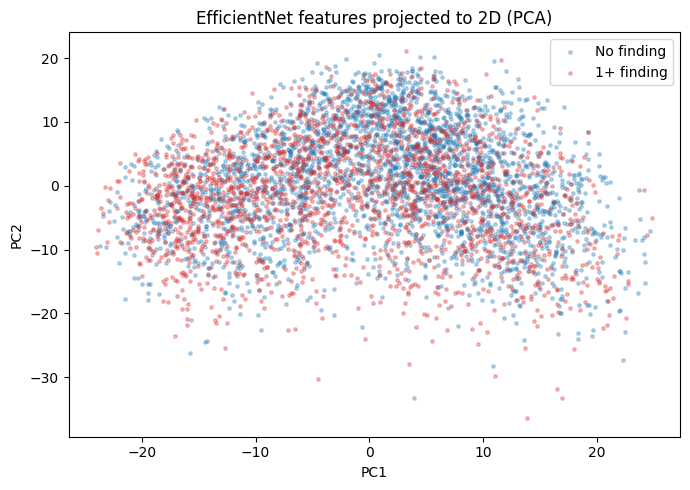

The first 2 principal components explain 14.6% of the variance.


In [9]:
p2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train)
proj = p2.transform(X_test)
any_finding = (y_test.sum(axis=1) > 0).astype(int)

plt.figure(figsize=(7, 5))
for v, c, lab in [(0, "tab:blue", "No finding"), (1, "tab:red", "1+ finding")]:
    mask = any_finding == v
    plt.scatter(proj[mask, 0], proj[mask, 1], s=6, alpha=0.3, c=c, label=lab)
plt.legend(); plt.title("EfficientNet features projected to 2D (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
print(f"The first 2 principal components explain "
      f"{p2.explained_variance_ratio_.sum()*100:.1f}% of the variance.")

## 3. Try a bunch of models and compare them

The assignment was to try different things and show the results, so rather than pick one model we
trained a spread of them and put them side by side. They all learn from the same features and get
tested on the same held-out 20%, so it's a fair comparison. We picked one model from each major family:

- Logistic regression (a linear model)
- Naive Bayes (a probabilistic model)
- k-Nearest Neighbors (looks at the most similar images)
- Random forest (lots of decision trees, averaged)
- Gradient boosting (decision trees built one after another to fix mistakes)
- Neural network (tried both a shallow and a deeper version)

We list the all-negative baseline first on purpose. It gets a high accuracy and an AUC of 0.5 (pure
chance), which is the clearest way to show that accuracy on its own is meaningless here. The table is
sorted by AUC so the best model is at the top.


In [10]:
def macro_auc(y_true, y_prob):
    # Average AUC over the conditions that actually have both classes present.
    try:
        valid = [i for i in range(NUM_CLASSES) if len(np.unique(y_true[:, i])) > 1]
        return roc_auc_score(y_true[:, valid], y_prob[:, valid], average="macro")
    except Exception:
        return float("nan")

def evaluate(name, y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {"model": name,
            "test_acc": (y_pred == y_true).mean(),
            "test_auc": macro_auc(y_true, y_prob),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "hamming_loss": hamming_loss(y_true, y_pred)}

# Columns to show, with train and test AUC next to each other so overfitting is visible.
SHOW_COLS = ["model", "test_acc", "test_auc", "train_auc", "macro_f1", "macro_recall", "hamming_loss"]

from sklearn.base import BaseEstimator, ClassifierMixin, clone

# A rare condition can be all-negative in the training split. Plain LogisticRegression
# refuses to fit on a single-class column, so wrap each per-condition model: if it only
# ever sees one class, just always predict that class.
class SafeBinary(BaseEstimator, ClassifierMixin):
    def __init__(self, base=None):
        self.base = base
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        if len(self.classes_) < 2:
            self.only_, self.est_ = int(self.classes_[0]), None
        else:
            self.only_, self.est_ = None, clone(self.base).fit(X, y)
        return self
    def predict_proba(self, X):
        if self.est_ is None:                      # one class only -> constant probability
            p = np.zeros((len(X), 2)); p[:, self.only_] = 1.0
            return p
        return self.est_.predict_proba(X)
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

def positive_proba(multi_estimator, X):
    return np.stack([est.predict_proba(X)[:, 1] for est in multi_estimator.estimators_], axis=1)

results = []
base = evaluate("Baseline (all negative)", y_test, np.zeros_like(y_test))
base["train_auc"] = 0.5
results.append(base)

# One model per condition (MultiOutputClassifier), each wrapped in SafeBinary. Same features,
# same test set for every model, a fair bake-off across model families.
zoo = {
    "Logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes":         GaussianNB(),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Random forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting":   HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
for name, est in zoo.items():
    clf = MultiOutputClassifier(SafeBinary(est))
    clf.fit(X_train, y_train)
    row = evaluate(name, y_test, positive_proba(clf, X_test))
    row["train_auc"] = macro_auc(y_train, positive_proba(clf, X_train))   # for overfitting check
    results.append(row)
    print(f"  trained: {name}")

print()
print(pd.DataFrame(results).sort_values("test_auc", ascending=False)[SHOW_COLS].to_string(index=False))

  trained: Logistic regression
  trained: Naive Bayes
  trained: k-Nearest Neighbors
  trained: Random forest
  trained: Gradient boosting

                  model  test_acc  test_auc  train_auc  macro_f1  macro_recall  hamming_loss
          Random forest  0.955671  0.702846   1.000000  0.000000      0.000000      0.044329
            Naive Bayes  0.696314  0.685588   0.727892  0.127644      0.584242      0.303686
    Logistic regression  0.857429  0.677193   0.955568  0.148478      0.293212      0.142571
      Gradient boosting  0.955343  0.671756   0.963466  0.009780      0.005060      0.044657
    k-Nearest Neighbors  0.955486  0.609743   0.899819  0.004048      0.002108      0.044514
Baseline (all negative)  0.955714  0.500000   0.500000  0.000000      0.000000      0.044286


Neural network (shallow) architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,798 (3.02 MB)

 Trainable params: 790,798 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 790,798

                               model  test_acc  test_auc  train_auc  macro_f1  macro_recall  hamming_loss
         Neural network (512-256-14)  0.739814  0.729354   0.838280  0.140065      0.542631      0.260186
Neural network deep (512-256-128-14)  0.734843  0.724564   0.796553  0.140475      0.547000      0.265157
                       Random forest  0.955671  0.702846   1.000000  0.000000      0.000000      0.044329
                         Naive Bayes  0.696314  0.685588   0.727892  0.127644      0.584242      0.303686
                 Logistic regression  0.857429  0.677193   0.955568  0.148478      0.293212      0.142571
                   Gradient boosting  0.955343  0.671756   0.963466  0.009780      0.005060      0.044657
                 k-Nearest Neighbors  0.955486  0.609743   0.899819  0.004048      0.002108      0.044514
             Baseline (all negative)  0.955714  0.500000   0.500000  0.000000      0.000000      0.044286

Shallow

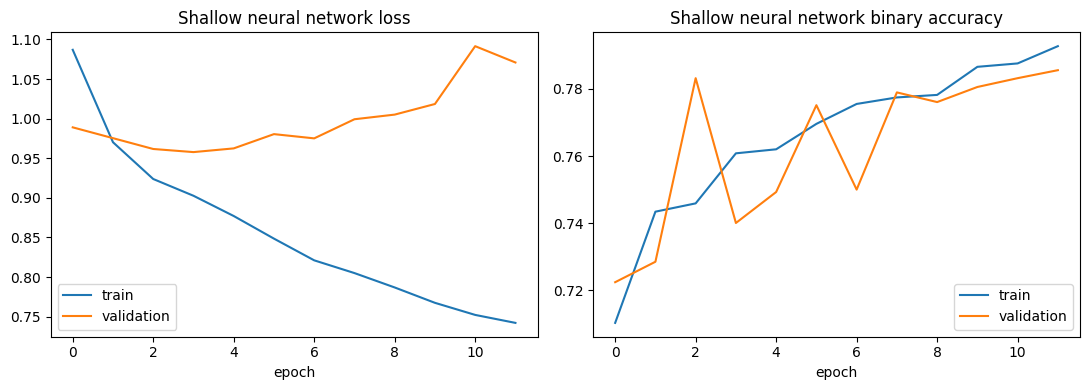

In [11]:
# Neural networks. The data is ~95% negative, so a plain loss lets the network "win" by predicting
# "no disease" for everything. We counter that with a WEIGHTED loss that up-weights the rare
# positive cases per condition (same idea as class_weight="balanced" for the others).
# Class idea (notebook 03, "stack more layers"): compare a shallow net vs a deeper one.
pos = y_train.sum(axis=0)
pos_weight = np.minimum((len(y_train) - pos) / np.maximum(pos, 1.0), 25.0).astype("float32")
_pw = tf.constant(pos_weight)

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    loss = -(_pw * y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    return tf.reduce_mean(loss)

def build_nn(hidden):
    m = keras.Sequential([layers.Input(shape=(1280,))])
    for h in hidden:
        m.add(layers.Dense(h, activation="relu")); m.add(layers.Dropout(0.3))
    m.add(layers.Dense(NUM_CLASSES, activation="sigmoid"))
    m.compile(optimizer="adam", loss=weighted_bce, metrics=["binary_accuracy"])
    return m

early = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)

# Shallow net (512 -> 256), THIS is the model we keep, tune, save, and ship in the app.
nn = build_nn([512, 256])
print("Neural network (shallow) architecture:")
nn.summary()
print(f"\nTotal trainable parameters: {nn.count_params():,}\n")
history = nn.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=60, batch_size=32, callbacks=[early], verbose=0)
nn_prob = nn.predict(X_test, verbose=0)
nn_train_prob = nn.predict(X_train, verbose=0)
row = evaluate("Neural network (512-256-14)", y_test, nn_prob)
row["train_auc"] = macro_auc(y_train, nn_train_prob)
results.append(row)

# Deeper net (512 -> 256 -> 128), does stacking another layer actually help here?
deep = build_nn([512, 256, 128])
deep.fit(X_train, y_train, validation_data=(X_val, y_val),
         epochs=60, batch_size=32, callbacks=[early], verbose=0)
drow = evaluate("Neural network deep (512-256-128-14)", y_test, deep.predict(X_test, verbose=0))
drow["train_auc"] = macro_auc(y_train, deep.predict(X_train, verbose=0))
results.append(drow)

res_df = pd.DataFrame(results).sort_values("test_auc", ascending=False)
print(res_df[SHOW_COLS].to_string(index=False))
print(f"\nShallow NN trained {len(history.history['loss'])} epochs (early stopping).")
print("The neural network has the best test AUC here, and it's the one we save and put in the")
print("app (it's also the only model that can produce a Grad-CAM heat map).")

# Train vs test for the model we keep (the assignment asks for both). Close numbers mean it
# generalised; a big train-much-higher-than-test gap would mean overfitting.
print("\nChosen model (shallow neural network) - train vs test:")
print(f"  accuracy:  train {(nn_train_prob.round() == y_train).mean():.3f}   "
      f"test {(nn_prob.round() == y_test).mean():.3f}")
print(f"  macro AUC: train {macro_auc(y_train, nn_train_prob):.3f}   "
      f"test {macro_auc(y_test, nn_prob):.3f}")

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Shallow neural network loss"); plt.xlabel("epoch"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["binary_accuracy"], label="train")
plt.plot(history.history["val_binary_accuracy"], label="validation")
plt.title("Shallow neural network binary accuracy"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

## 4. Pick a sensible cutoff for each condition

AUC tells us how well the model ranks sick vs. healthy, but it never has to commit to an actual yes/no
answer. To do that you need a cutoff: if the predicted probability is above it, call it positive. The
usual default is 0.5, but that's a bad choice for rare conditions, because the model rarely gets that
confident and ends up saying "no" to almost everything, which means it misses real cases.

So instead of one cutoff for everything, we choose a separate cutoff for each condition. We pick each
one on the validation set (never the test set, so we're not cheating) to maximize its F2 score. F2 is
like F1 but it weighs recall twice as much as precision, which fits the medical setting where missing a
real case is worse than a false alarm. The table below shows how the precision/recall balance shifts
versus a flat 0.5. Notice the AUC doesn't change, because we only moved the cutoff, not the model.


In [12]:
# Choose a per-condition threshold on the VALIDATION set by maximising F2 (the F-score that
# weights recall 2x over precision), in medicine, missing disease usually costs more than a
# false alarm, so we deliberately favour catching cases.
val_prob = nn.predict(X_val, verbose=0)
thresholds = np.full(NUM_CLASSES, 0.5)
for i in range(NUM_CLASSES):
    if len(np.unique(y_val[:, i])) < 2:
        continue
    best_t, best_f2 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 19):
        f2 = fbeta_score(y_val[:, i], (val_prob[:, i] >= t).astype(int), beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    thresholds[i] = best_t

# Compare the neural network at 0.5 vs the tuned thresholds, on the TEST set.
default_row = evaluate("NN @ 0.5 (default)", y_test, nn_prob, thr=0.5)
tuned_pred  = (nn_prob >= thresholds).astype(int)
tuned_row = {"model": "NN @ tuned thresholds",
             "test_acc": (tuned_pred == y_test).mean(),
             "test_auc": default_row["test_auc"],            # AUC is threshold-independent
             "macro_f1": f1_score(y_test, tuned_pred, average="macro", zero_division=0),
             "macro_recall": recall_score(y_test, tuned_pred, average="macro", zero_division=0),
             "hamming_loss": hamming_loss(y_test, tuned_pred)}
show = ["model", "test_acc", "test_auc", "macro_f1", "macro_recall", "hamming_loss"]
print(pd.DataFrame([default_row, tuned_row])[show].to_string(index=False))
print("\nBlanket 0.5  ->  tuned per-condition thresholds (test set):")
print(f"  macro recall:    {default_row['macro_recall']:.3f}  ->  {tuned_row['macro_recall']:.3f}")
print(f"  macro F1:        {default_row['macro_f1']:.3f}  ->  {tuned_row['macro_f1']:.3f}")
print(f"  accuracy:        {default_row['test_acc']:.3f}  ->  {tuned_row['test_acc']:.3f}")
print("\nThe tuned thresholds give each condition its own F2-optimised operating point instead")
print("of a blanket 0.5, shifting the precision/recall balance (see the per-condition table).")
print("AUC is identical for both rows: a threshold only moves the decision cutoff, not the")
print("model's ranking ability, which is exactly why AUC, not accuracy, is the headline metric.")

                model  test_acc  test_auc  macro_f1  macro_recall  hamming_loss
   NN @ 0.5 (default)  0.739814  0.729354  0.140065      0.542631      0.260186
NN @ tuned thresholds  0.709857  0.729354  0.148113      0.576694      0.290143

Blanket 0.5  ->  tuned per-condition thresholds (test set):
  macro recall:    0.543  ->  0.577
  macro F1:        0.140  ->  0.148
  accuracy:        0.740  ->  0.710

The tuned thresholds give each condition its own F2-optimised operating point instead
of a blanket 0.5, shifting the precision/recall balance (see the per-condition table).
AUC is identical for both rows: a threshold only moves the decision cutoff, not the
model's ranking ability, which is exactly why AUC, not accuracy, is the headline metric.


## 5. Where it works and where it fails

An overall AUC is fine, but it hides which conditions the model is actually good or bad at. The table
below breaks it down per condition, sorted by how many examples were in the test set. Recall is the
column to watch: it's the share of real cases we caught. The common conditions tend to do okay, while
the rare ones are hard because there just aren't many examples to learn from.

After that, the confusion matrix gives a single picture. Multi-label is awkward to show in one grid, so
to keep it readable we reduce each X-ray to its single main finding and compare that to what the model
flagged most strongly. The diagonal is where it got the main finding right.


In [13]:
# Per-condition breakdown of the tuned neural network.
rows = []
for i, c in enumerate(CLASSES):
    support = int(y_test[:, i].sum())
    auc = roc_auc_score(y_test[:, i], nn_prob[:, i]) if len(np.unique(y_test[:, i])) > 1 else float("nan")
    pred_i = (nn_prob[:, i] >= thresholds[i]).astype(int)
    rows.append({"condition": c, "test_positives": support, "threshold": round(float(thresholds[i]), 2),
                 "precision": precision_score(y_test[:, i], pred_i, zero_division=0),
                 "recall":    recall_score(y_test[:, i], pred_i, zero_division=0),
                 "auc": auc})
per_class = pd.DataFrame(rows).sort_values("test_positives", ascending=False)
print(per_class.to_string(index=False))
print("\nRecall (sensitivity) on the common conditions is the number to watch in a medical setting.")

         condition  test_positives  threshold  precision   recall      auc
      Infiltration             750       0.30   0.177867 0.949333 0.698196
          Effusion             472       0.50   0.178493 0.692797 0.757903
       Atelectasis             454       0.50   0.135396 0.742291 0.677322
            Nodule             234       0.40   0.054580 0.850427 0.629332
      Pneumothorax             176       0.65   0.108470 0.414773 0.763920
              Mass             171       0.55   0.062219 0.485380 0.674554
      Cardiomegaly             169       0.65   0.147687 0.491124 0.814602
     Consolidation             168       0.55   0.075841 0.577381 0.728837
Pleural_Thickening             149       0.45   0.050181 0.651007 0.700391
          Fibrosis             117       0.45   0.055369 0.564103 0.747005
         Emphysema              82       0.70   0.113990 0.268293 0.764325
             Edema              79       0.60   0.064125 0.468354 0.825964
         Pneumonia       

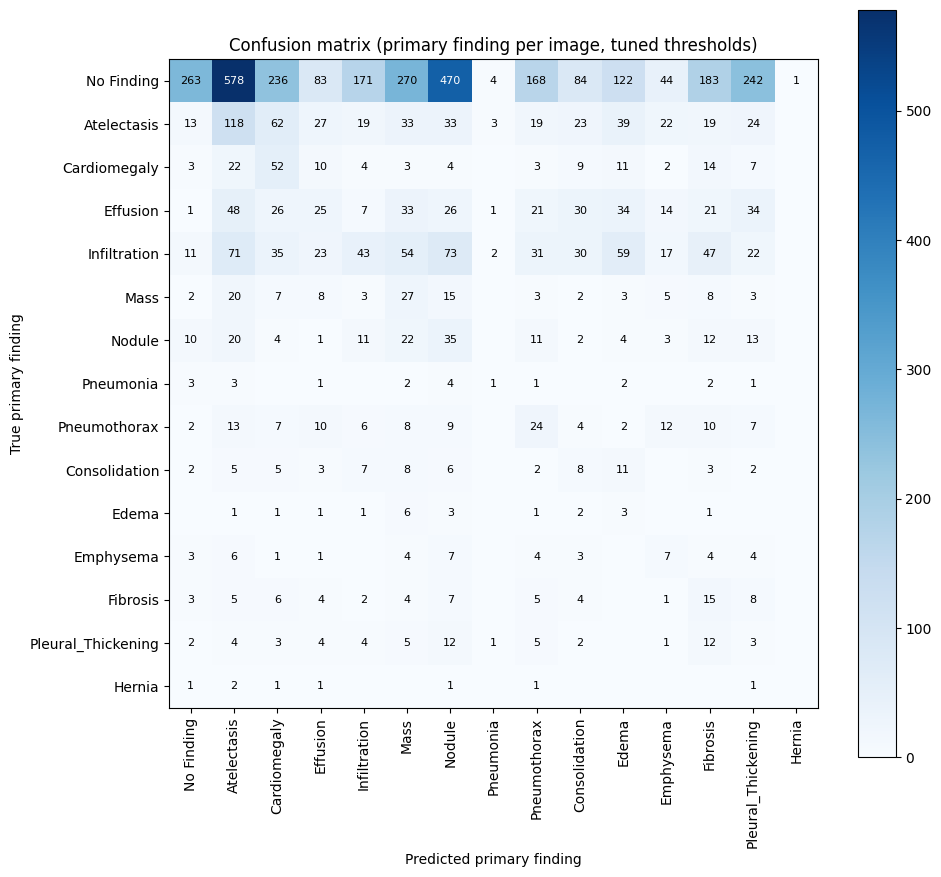

In [14]:
# Primary-finding confusion matrix, using the tuned thresholds.
labels_axis = ["No Finding"] + CLASSES

def true_primary(vec):
    idx = np.where(vec == 1)[0]
    return CLASSES[idx[0]] if len(idx) else "No Finding"

def pred_primary(prob):
    over = prob >= thresholds
    return CLASSES[int(np.argmax(prob * over))] if over.any() else "No Finding"

y_true_primary = [true_primary(v) for v in y_test]
y_pred_primary = [pred_primary(p) for p in nn_prob]
cm = confusion_matrix(y_true_primary, y_pred_primary, labels=labels_axis)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_axis))); ax.set_xticklabels(labels_axis, rotation=90)
ax.set_yticks(range(len(labels_axis))); ax.set_yticklabels(labels_axis)
ax.set_xlabel("Predicted primary finding"); ax.set_ylabel("True primary finding")
ax.set_title("Confusion matrix (primary finding per image, tuned thresholds)")
for i in range(len(labels_axis)):
    for j in range(len(labels_axis)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
fig.colorbar(im); plt.tight_layout(); plt.show()

## 5b. Two things we tested

The NIH documentation points out two things worth checking, so we ran a quick experiment for each.

**Does the way we split the data matter?** There are 112,120 images but only 30,805 patients, so each
patient has several X-rays. If we split by image at random, the same patient can end up in both train
and test, which leaks information and can make the score look better than it really is. The honest way
is to split by patient. Below we compare both.

**Would more training data help?** Since we used a slice of the data, we train the model on increasing
amounts and watch the test AUC. If the line is still climbing, more data would help; if it flattens,
we have hit the limit of the frozen features (and the next step would be to fine-tune the network,
which needs a GPU).


In [15]:
# Does the split matter? Compare a random image split vs a patient-level split, same model both ways.
from sklearn.model_selection import GroupShuffleSplit
patient_of = df.set_index("Image Index")["Patient ID"].to_dict()
groups = np.array([patient_of[n] for n in used_names])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
g_tr, g_te = next(gss.split(X, y, groups))
psc = StandardScaler().fit(X[g_tr])
p_nn = build_nn([512, 256])
p_nn.fit(psc.transform(X[g_tr]), y[g_tr], epochs=40, batch_size=32, callbacks=[early], verbose=0)
patient_auc = macro_auc(y[g_te], p_nn.predict(psc.transform(X[g_te]), verbose=0))
random_auc = macro_auc(y_test, nn_prob)
shared = len(set(groups[g_tr]) & set(groups[g_te]))

print(f"Random image split   ->  neural-net test AUC: {random_auc:.3f}")
print(f"Patient-level split  ->  neural-net test AUC: {patient_auc:.3f}")
print(f"Patients shared between train and test, patient-level split: {shared} (should be 0)")
print("\nThe patient-level number is the honest one. If it is a bit lower, the random split was")
print("slightly optimistic because the same patient appeared on both sides.")

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


Random image split   ->  neural-net test AUC: 0.729
Patient-level split  ->  neural-net test AUC: 0.670
Patients shared between train and test, patient-level split: 0 (should be 0)

The patient-level number is the honest one. If it is a bit lower, the random split was
slightly optimistic because the same patient appeared on both sides.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


  trained on   1000 images  ->  test AUC 0.619


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


  trained on   2500 images  ->  test AUC 0.644


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


  trained on   5000 images  ->  test AUC 0.675


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


  trained on  10000 images  ->  test AUC 0.686


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: binary_accuracy,loss
  current = self.get_monitor_value(logs)


  trained on  14999 images  ->  test AUC 0.712


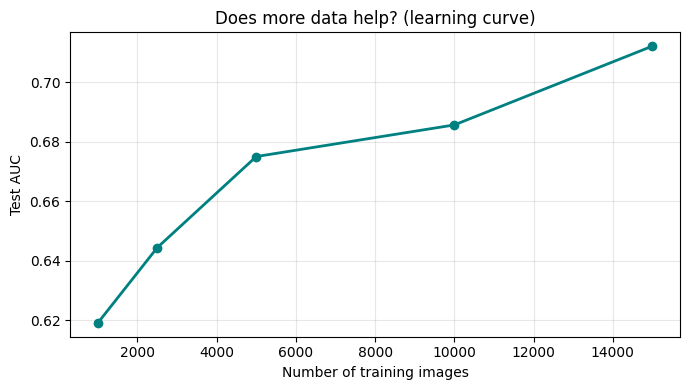


Still climbing at the right edge -> more data would help a little more.
Flattened out -> we have hit the frozen-feature ceiling; the next step is fine-tuning (GPU).


In [16]:
# Would more data help? Train on increasing amounts and watch the test AUC (a learning curve).
sizes = sorted({s for s in [1000, 2500, 5000, 10000, len(X_train)] if s <= len(X_train)})
lc_auc = []
for n in sizes:
    m = build_nn([512, 256])
    m.fit(X_train[:n], y_train[:n], epochs=40, batch_size=32, callbacks=[early], verbose=0)
    a = macro_auc(y_test, m.predict(X_test, verbose=0))
    lc_auc.append(a); print(f"  trained on {n:>6} images  ->  test AUC {a:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(sizes, lc_auc, "o-", color="teal", linewidth=2)
plt.xlabel("Number of training images"); plt.ylabel("Test AUC")
plt.title("Does more data help? (learning curve)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("\nStill climbing at the right edge -> more data would help a little more.")
print("Flattened out -> we have hit the frozen-feature ceiling; the next step is fine-tuning (GPU).")

## 6. Explain a prediction with Grad-CAM, and save the model

It's not enough for the model to be right; we want to know it's looking at the right part of the image
and not at some artifact in the corner. Grad-CAM does that. It produces a heat map over the X-ray
showing which region pushed the prediction the most.

To make it work we rebuild the network so it takes a whole image (instead of the pre-computed numbers),
keeping EfficientNet's spatial output and attaching the dense head we already trained. We save that
whole image model, along with the class names and the tuned cutoffs, into the `cxr_app/` folder. That's
exactly what the web app in the next section loads. The pictures below are a preview of what the app
shows: a couple of held-out X-rays with the prediction and the heat map side by side.


In [17]:
# End-to-end image model, built FUNCTIONALLY (Keras-3 friendly): image -> EfficientNet
# convolutional feature map -> global pooling -> the trained dense head. EfficientNet with
# pooling=None already outputs the 7x7 feature map Grad-CAM needs, so we tap it directly.
spatial = EfficientNetB0(include_top=False, weights="imagenet",
                         input_shape=IMG_SIZE + (3,), pooling=None)
spatial.trainable = False

inputs   = keras.Input(shape=IMG_SIZE + (3,))
feat_map = spatial(inputs)                       # (None, 7, 7, 1280) conv feature map
x = layers.GlobalAveragePooling2D()(feat_map)
# Bake the StandardScaler into the model so the app needs no separate scaler: this layer
# standardises the pooled features with the exact mean/variance fit on the training set.
x = layers.Normalization(axis=-1, mean=scaler.mean_, variance=scaler.var_, name="norm")(x)
x = layers.Dense(512, activation="relu", name="d1")(x); x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="d2")(x); x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation="sigmoid", name="out")(x)

# The model exposes TWO outputs: [conv feature map, predictions]. Both are built from the
# same input graph, so Grad-CAM just reads output 0 and predictions output 1, no fragile
# layer surgery, and it behaves identically after the model is saved and reloaded in the app.
image_model = keras.Model(inputs, [feat_map, out], name="cxr_image_model")

# Copy the trained dense-head weights from the feature-based NN.
trained_dense = [l for l in nn.layers if isinstance(l, layers.Dense)]
for dst_name, src in zip(["d1", "d2", "out"], trained_dense):
    image_model.get_layer(dst_name).set_weights(src.get_weights())

def gradcam(img_arr, class_idx):
    with tf.GradientTape() as tape:
        conv_out, preds = image_model(img_arr[None])
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy()

def load_image(name):
    with tarfile.open(image_to_archive[name], "r:gz") as tar:
        for m in tar.getmembers():
            if os.path.basename(m.name) == name:
                return Image.open(io.BytesIO(tar.extractfile(m).read())).convert("RGB").resize(IMG_SIZE)

# Save the model + metadata for the app.
image_model.save(os.path.join(APP_DIR, "cxr14_model.keras"))
json.dump(CLASSES, open(os.path.join(APP_DIR, "classes.json"), "w"))
json.dump([float(t) for t in thresholds], open(os.path.join(APP_DIR, "thresholds.json"), "w"))
print("Saved model + metadata to", APP_DIR)

Saved model + metadata to /content/cxr_app


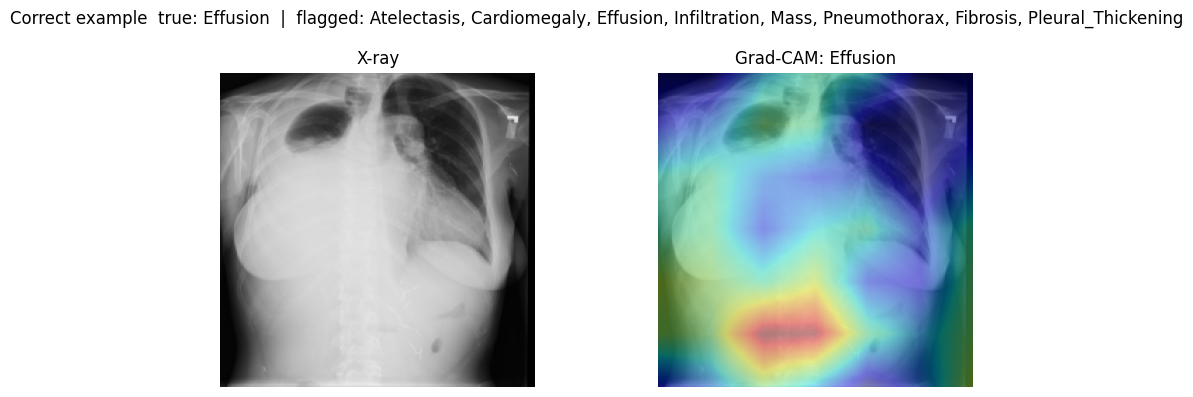

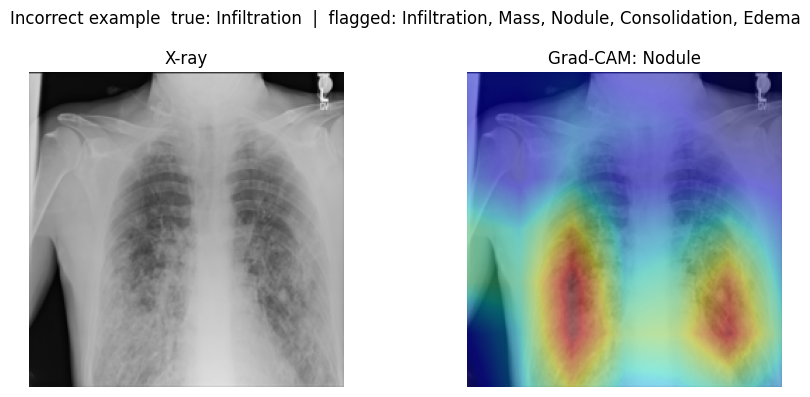

Bundled 7 sample images (+ ground-truth labels) in /content/cxr_app/samples


In [18]:
# Preview demo: a few held-out X-rays with predictions and Grad-CAM (what the app shows).
from scipy.ndimage import zoom

os.makedirs(os.path.join(APP_DIR, "samples"), exist_ok=True)

def show_and_save(idx, tag):
    name = names_test[idx]
    img = load_image(name)
    arr = np.asarray(img, np.float32)   # raw 0-255 for the model; PIL img used for display
    prob = nn_prob[idx]
    cls = int(prob.argmax())
    cam = gradcam(arr, cls)
    cam_big = zoom(cam, (IMG_SIZE[0]/cam.shape[0], IMG_SIZE[1]/cam.shape[1]), order=1)
    flagged = [CLASSES[i] for i in range(NUM_CLASSES) if prob[i] >= thresholds[i]]
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(img); ax[0].set_title("X-ray"); ax[0].axis("off")
    ax[1].imshow(img); ax[1].imshow(cam_big, cmap="jet", alpha=0.4)
    ax[1].set_title("Grad-CAM: " + CLASSES[cls]); ax[1].axis("off")
    fig.suptitle(f"{tag}  true: {true_primary(y_test[idx])}  |  flagged: {', '.join(flagged) or 'none'}")
    plt.tight_layout(); plt.show()
    img.save(os.path.join(APP_DIR, "samples", name))   # bundle a few samples for the app

# One correct and one incorrect non-trivial example, plus a couple of extra samples.
correct_idx = wrong_idx = None
for i in range(len(y_test)):
    t, p = true_primary(y_test[i]), pred_primary(nn_prob[i])
    if t != "No Finding" and t == p and correct_idx is None: correct_idx = i
    if t != "No Finding" and t != p and wrong_idx is None:   wrong_idx = i
    if correct_idx is not None and wrong_idx is not None:    break

if correct_idx is not None: show_and_save(correct_idx, "Correct example")
else: print("No correct non-trivial example in this sample.")
if wrong_idx is not None: show_and_save(wrong_idx, "Incorrect example")
else: print("No incorrect non-trivial example in this sample.")

# Save a few more sample images (no plot) so the app has options to demo.
for i in list(range(len(names_test)))[:6]:
    load_image(names_test[i]).save(os.path.join(APP_DIR, "samples", names_test[i]))

# Record each bundled sample's TRUE findings so the app can show expected vs predicted.
truth_by_name = df.set_index("Image Index")["Finding Labels"].astype(str).to_dict()
sample_labels = {fn: truth_by_name.get(fn, "unknown")
                 for fn in os.listdir(os.path.join(APP_DIR, "samples"))}
json.dump(sample_labels, open(os.path.join(APP_DIR, "sample_labels.json"), "w"))
print("Bundled", len(sample_labels), "sample images (+ ground-truth labels) in",
      os.path.join(APP_DIR, "samples"))

## 6b. Deep learning that needs a GPU: a CNN from scratch, and fine-tuning

These are the two heaviest deep-learning techniques in the project, so the cell below runs them **only
if a GPU is available** (easiest: Google Colab, Runtime > Change runtime type > GPU) and otherwise
skips with instructions.

1. **A convolutional neural network built from scratch** (the same Conv -> Pool -> Flatten -> Dense
   idea as the class MNIST notebook). With only a slice of the data it usually scores *below* transfer
   learning, which is exactly why transfer learning is worth using.
2. **Fine-tuning** the pretrained EfficientNet in two stages (warm up the new head, then unfreeze the
   whole network at a very low learning rate). This is the real accuracy lever, and it's how the
   published CheXNet model reaches 0.80+.

Put next to the frozen transfer-learning model from earlier, this gives the full deep-learning
progression: **CNN from scratch  ->  transfer learning (frozen)  ->  fine-tuning.**


In [19]:
# CNN from scratch + two-stage fine-tuning. Needs a GPU; skipped automatically on CPU (too slow).
import tensorflow as tf
if not tf.config.list_physical_devices("GPU"):
    print("No GPU detected - skipping the from-scratch CNN and fine-tuning (far too slow on a CPU).")
    print("To run them: open this notebook in Google Colab, choose Runtime > Change runtime type > GPU,")
    print("then Run all. With a GPU this takes roughly 40-60 minutes and shows the deep-learning")
    print("progression: CNN from scratch -> transfer learning -> fine-tuning.")
else:
    print("GPU detected - training a CNN from scratch and fine-tuning EfficientNet.\n")

    # 1) Load images as raw pixels (uint8 keeps memory down). Capped for memory safety on Colab.
    FT_SIZE = int(os.environ.get("CXR_FT_SIZE", min(len(available), 12000)))
    ft_df = available.sample(n=FT_SIZE, random_state=RANDOM_STATE)
    by_arch = {}
    for _, row in ft_df.iterrows():
        by_arch.setdefault(image_to_archive[row["Image Index"]], []).append(row)
    imgs, labs = [], []
    for path, rows in by_arch.items():
        want = {r["Image Index"]: r for r in rows}
        with tarfile.open(path, "r:gz") as tar:
            for m in tar.getmembers():
                nm = os.path.basename(m.name)
                if nm in want:
                    im = Image.open(io.BytesIO(tar.extractfile(m).read())).convert("RGB").resize(IMG_SIZE)
                    imgs.append(np.asarray(im, np.uint8)); labs.append(want[nm]["multi_hot"])
    Ximg = np.array(imgs); yimg = np.array(labs, np.float32)
    print("  loaded", Ximg.shape[0], "images for fine-tuning")

    # 2) Train / validation / test split (70 / 15 / 15).
    ai = np.arange(len(Ximg))
    a_tr, a_tmp = train_test_split(ai, test_size=0.3, random_state=RANDOM_STATE)
    a_va, a_te = train_test_split(a_tmp, test_size=0.5, random_state=RANDOM_STATE)

    # Memory-light pipeline: keep the images in RAM once, feed them by index (no big copy
    # into the TensorFlow graph, which is what crashed the session before).
    def ds(idx, training):
        idx = np.asarray(idx)
        d = tf.data.Dataset.from_tensor_slices(idx)
        if training:
            d = d.shuffle(len(idx), reshuffle_each_iteration=True)
        def fetch(i):
            x = tf.numpy_function(lambda j: Ximg[int(j)].astype("float32"), [i], tf.float32)
            y = tf.numpy_function(lambda j: yimg[int(j)], [i], tf.float32)
            x.set_shape(IMG_SIZE + (3,)); y.set_shape((NUM_CLASSES,))
            return x, y
        return d.map(fetch, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

    # Weighted loss so the rare positives still count (used by both models below).
    fp = yimg[a_tr].sum(axis=0)
    fpw = tf.constant(np.minimum((len(a_tr) - fp) / np.maximum(fp, 1.0), 25.0).astype("float32"))
    def ft_loss(yt, yp):
        yp = tf.clip_by_value(yp, 1e-7, 1.0 - 1e-7)
        return tf.reduce_mean(-(fpw * yt * tf.math.log(yp) + (1.0 - yt) * tf.math.log(1.0 - yp)))

    # ---- Deep learning model 1: a CNN built from scratch (same idea as the class MNIST notebook) ----
    print("Training a CNN from scratch (Conv -> Pool -> Flatten -> Dense) ...")
    cnn = keras.Sequential([
        keras.Input(IMG_SIZE + (3,)),
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"), layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="sigmoid"),
    ])
    cnn.compile(optimizer="adam", loss=ft_loss, metrics=["binary_accuracy"])
    cnn.fit(ds(a_tr, True), validation_data=ds(a_va, False), epochs=10,
            callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)], verbose=2)
    cnn_auc = macro_auc(yimg[a_te], cnn.predict(ds(a_te, False), verbose=0))
    print(f"CNN from scratch: test AUC {cnn_auc:.3f}\n")

    # ---- Deep learning model 2: fine-tune the pretrained EfficientNet (two stages) ----
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,), pooling=None)
    inp = keras.Input(IMG_SIZE + (3,))
    fmap = base(inp)
    z = layers.GlobalAveragePooling2D()(fmap)
    z = layers.Dense(256, activation="relu")(z); z = layers.Dropout(0.3)(z)
    outp = layers.Dense(NUM_CLASSES, activation="sigmoid", name="out")(z)
    model_ft = keras.Model(inp, outp)

    # Stage 1: warm up the new head with the backbone frozen, so big random gradients
    # don't wreck the pretrained features.
    base.trainable = False
    model_ft.compile(optimizer=keras.optimizers.Adam(1e-3), loss=ft_loss, metrics=["binary_accuracy"])
    print("Stage 1: training the head (backbone frozen) ...")
    model_ft.fit(ds(a_tr, True), validation_data=ds(a_va, False), epochs=4, verbose=2)

    # Stage 2: unfreeze the WHOLE backbone and fine-tune slowly (low learning rate).
    base.trainable = True
    model_ft.compile(optimizer=keras.optimizers.Adam(1e-5), loss=ft_loss, metrics=["binary_accuracy"])
    print("\nStage 2: fine-tuning the whole network (low learning rate) ...")
    model_ft.fit(ds(a_tr, True), validation_data=ds(a_va, False), epochs=15,
                 callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
                 verbose=2)

    # 4) Compare the fine-tuned model to the earlier frozen-backbone neural net.
    ft_auc = macro_auc(yimg[a_te], model_ft.predict(ds(a_te, False), verbose=0))
    print(f"\nDeep-learning progression (test AUC):")
    print(f"  CNN from scratch:              {cnn_auc:.3f}")
    print(f"  Transfer learning (frozen):    {macro_auc(y_test, nn_prob):.3f}")
    print(f"  Fine-tuned (unfrozen, 2-stage):{ft_auc:.3f}")

    # 5) Re-tune per-condition thresholds (F2) for the new model, on validation.
    ft_val = model_ft.predict(ds(a_va, False), verbose=0)
    ft_thr = np.full(NUM_CLASSES, 0.5)
    for i in range(NUM_CLASSES):
        if len(np.unique(yimg[a_va][:, i])) < 2:
            continue
        bt, bf = 0.5, -1.0
        for t in np.linspace(0.05, 0.95, 19):
            f = fbeta_score(yimg[a_va][:, i], (ft_val[:, i] >= t).astype(int), beta=2, zero_division=0)
            if f > bf:
                bf, bt = f, t
        ft_thr[i] = bt

    # 6) Save the fine-tuned model in the same two-output form so the app + Grad-CAM still work.
    keras.Model(inp, [fmap, outp]).save(os.path.join(APP_DIR, "cxr14_model.keras"))
    json.dump([float(t) for t in ft_thr], open(os.path.join(APP_DIR, "thresholds.json"), "w"))
    print("\nSaved the fine-tuned model to the app folder - it now powers the app and the Grad-CAM demo.")

GPU detected - training a CNN from scratch and fine-tuning EfficientNet.

  loaded 12000 images for fine-tuning
Training a CNN from scratch (Conv -> Pool -> Flatten -> Dense) ...
Epoch 1/10
263/263 - 20s - 78ms/step - binary_accuracy: 0.6828 - loss: 1.0918 - val_binary_accuracy: 0.7595 - val_loss: 1.0859
Epoch 2/10
263/263 - 8s - 30ms/step - binary_accuracy: 0.7450 - loss: 1.0607 - val_binary_accuracy: 0.8431 - val_loss: 1.0743
Epoch 3/10
263/263 - 8s - 30ms/step - binary_accuracy: 0.7478 - loss: 1.0491 - val_binary_accuracy: 0.8548 - val_loss: 1.0701
Epoch 4/10
263/263 - 7s - 28ms/step - binary_accuracy: 0.7666 - loss: 1.0406 - val_binary_accuracy: 0.8335 - val_loss: 1.0622
Epoch 5/10
263/263 - 8s - 30ms/step - binary_accuracy: 0.7633 - loss: 1.0300 - val_binary_accuracy: 0.7814 - val_loss: 1.0699
Epoch 6/10
263/263 - 10s - 37ms/step - binary_accuracy: 0.7676 - loss: 1.0186 - val_binary_accuracy: 0.7984 - val_loss: 1.0534
Epoch 7/10
263/263 - 7s - 28ms/step - binary_accuracy: 0.7724 -

## 7. The web app

This cell writes out `cxr_app/app.py`, a little web app that loads the model we just saved. It has two
modes, switched with a radio button in the sidebar:

**Classify.** You upload a chest X-ray (or pick one of the bundled samples) and it shows the predicted
conditions, which ones it flags using the tuned cutoffs, and the Grad-CAM heat map. For the bundled
samples it also knows the real answer, so it shows the true labels next to the prediction. After each
prediction you can tap *Looks right* / *Looks off*, a simple human-in-the-loop check that gets logged.

**Monitoring.** Every classification appends a row to `cxr_app/logs/predictions_log.csv` (timestamp,
image, top prediction, all 14 probabilities, how many conditions were flagged). The Monitoring tab reads
that log and shows population-level views: how often each condition is flagged, the spread of
confidence, the user-feedback tally, and the most recent cases. It's the lightweight, self-contained
version of a clinical-analytics dashboard, and the same CSV could just as easily feed Power BI or Google
Sheets. This is what turns a one-image demo into something you could actually monitor in use.

To run it, open a terminal in this folder and type:

```
pip install -r cxr_app/requirements.txt
streamlit run cxr_app/app.py
```

That opens a tab at http://localhost:8501. Everything the app needs is inside the `cxr_app/` folder
(model, classes, thresholds, sample images, and a `requirements.txt`), so you can zip that folder up and
share the whole working app.


In [ ]:
app_code = '# Chest X-ray Classifier - Streamlit app\n# Run with:  streamlit run app.py\n# Loads the model trained by the notebook and lets you upload an X-ray to get\n# per-condition predictions plus a Grad-CAM heat map of where the model looked.\n#\n# Two modes (radio in the sidebar):\n#   * Classify    - upload/pick an X-ray, see predictions + Grad-CAM.\n#   * Monitoring  - population-level view built from the prediction log the app\n#                   writes on every classification (the lightweight, self-contained\n#                   version of a Power BI / clinical-analytics dashboard).\nimport os, io, json, csv, hashlib, datetime, random\nimport numpy as np\nimport streamlit as st\nimport tensorflow as tf\nfrom tensorflow import keras\nfrom PIL import Image\nimport matplotlib.pyplot as plt\nfrom scipy.ndimage import zoom\n\nHERE = os.path.dirname(os.path.abspath(__file__))\nIMG_SIZE = (224, 224)\nLOG_DIR = os.path.join(HERE, "logs")\nPRED_LOG = os.path.join(LOG_DIR, "predictions_log.csv")\nFEEDBACK_LOG = os.path.join(LOG_DIR, "feedback_log.csv")\n\nst.set_page_config(page_title="Chest X-ray Classifier", layout="centered")\n\n@st.cache_resource\ndef load_everything():\n    # Saved model has two outputs: [conv feature map, predictions].\n    model = keras.models.load_model(os.path.join(HERE, "cxr14_model.keras"))\n    classes = json.load(open(os.path.join(HERE, "classes.json")))\n    thresholds = np.array(json.load(open(os.path.join(HERE, "thresholds.json"))))\n    return model, classes, thresholds\n\nmodel, CLASSES, THRESHOLDS = load_everything()\n\n# Ground-truth labels for the bundled sample images (for expected-vs-predicted display).\ntry:\n    SAMPLE_LABELS = json.load(open(os.path.join(HERE, "sample_labels.json")))\nexcept Exception:\n    SAMPLE_LABELS = {}\n\ndef predict(arr):\n    conv, preds = model(arr[None])\n    return preds[0].numpy()\n\ndef gradcam(arr, class_idx):\n    with tf.GradientTape() as tape:\n        conv_out, preds = model(arr[None])\n        loss = preds[:, class_idx]\n    grads = tape.gradient(loss, conv_out)\n    weights = tf.reduce_mean(grads, axis=(0, 1, 2))\n    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)\n    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)\n    return cam.numpy()\n\n# ---- Lightweight logging ----------------------------------------------------\n# Every classification appends one row to predictions_log.csv. This is what turns\n# a single-image demo into something you can monitor at the population level, and\n# it is the data source the Monitoring tab (and any external BI tool) reads from.\ndef log_prediction(source, probs, flagged):\n    os.makedirs(LOG_DIR, exist_ok=True)\n    new = not os.path.exists(PRED_LOG)\n    with open(PRED_LOG, "a", newline="") as f:\n        w = csv.writer(f)\n        if new:\n            w.writerow(["timestamp", "source", "top_prediction", "top_probability",\n                        "num_flagged"] + CLASSES)\n        top = int(np.argmax(probs))\n        w.writerow([datetime.datetime.now().isoformat(timespec="seconds"), source,\n                    CLASSES[top], round(float(probs[top]), 4), len(flagged)]\n                   + [round(float(p), 4) for p in probs])\n\ndef log_feedback(source, verdict, top_prediction):\n    os.makedirs(LOG_DIR, exist_ok=True)\n    new = not os.path.exists(FEEDBACK_LOG)\n    with open(FEEDBACK_LOG, "a", newline="") as f:\n        w = csv.writer(f)\n        if new:\n            w.writerow(["timestamp", "source", "top_prediction", "feedback"])\n        w.writerow([datetime.datetime.now().isoformat(timespec="seconds"),\n                    source, top_prediction, verdict])\n\n# ---- Mode switch ------------------------------------------------------------\nmode = st.sidebar.radio("Mode", ["Classify", "Monitoring"], index=0)\nst.sidebar.caption("Classify runs the model on one X-ray. Monitoring summarises "\n                   "everything classified so far from the prediction log.")\n\n# =============================================================================\n# MONITORING TAB\n# =============================================================================\ndef monitoring_view():\n    import pandas as pd\n    st.title("Monitoring dashboard")\n    st.write("Population-level view of every X-ray this app has classified. "\n             "Built from `logs/predictions_log.csv`, which the app appends to on "\n             "each prediction - the same data could feed Power BI or any BI tool.")\n    if not os.path.exists(PRED_LOG):\n        st.info("No predictions logged yet. Switch to **Classify**, run a few "\n                "X-rays, then come back.")\n        return\n    df = pd.read_csv(PRED_LOG)\n    if df.empty:\n        st.info("The prediction log is empty. Classify a few X-rays first.")\n        return\n\n    c1, c2, c3 = st.columns(3)\n    c1.metric("X-rays classified", len(df))\n    c2.metric("Avg findings flagged / image", f"{df[\'num_flagged\'].mean():.2f}")\n    c3.metric("Avg top-prediction confidence", f"{df[\'top_probability\'].mean():.2f}")\n\n    st.subheader("How often each condition is flagged")\n    flag_counts = {c: int((df[c] >= THRESHOLDS[i]).sum()) for i, c in enumerate(CLASSES)}\n    fc = pd.Series(flag_counts).sort_values(ascending=True)\n    fig, ax = plt.subplots(figsize=(7, 5))\n    ax.barh(fc.index, fc.values, color="#10495C")\n    ax.set_xlabel("number of images flagged (prob >= tuned threshold)")\n    fig.tight_layout()\n    st.pyplot(fig)\n\n    st.subheader("Confidence distribution (top prediction per image)")\n    fig2, ax2 = plt.subplots(figsize=(7, 3))\n    ax2.hist(df["top_probability"], bins=20, color="#E07A33", edgecolor="white")\n    ax2.set_xlabel("top-prediction probability"); ax2.set_ylabel("images")\n    fig2.tight_layout()\n    st.pyplot(fig2)\n\n    st.subheader("Per-condition summary")\n    per = pd.DataFrame({\n        "Condition": CLASSES,\n        "Times flagged": [int((df[c] >= THRESHOLDS[i]).sum()) for i, c in enumerate(CLASSES)],\n        "Flagged %": [round(float((df[c] >= THRESHOLDS[i]).mean()) * 100, 1)\n                      for i, c in enumerate(CLASSES)],\n        "Avg probability": [round(float(df[c].mean()), 3) for c in CLASSES],\n    }).sort_values("Times flagged", ascending=False)\n    st.dataframe(per, use_container_width=True, hide_index=True)\n\n    if os.path.exists(FEEDBACK_LOG):\n        fb = pd.read_csv(FEEDBACK_LOG)\n        if not fb.empty:\n            st.subheader("User feedback")\n            counts = fb["feedback"].value_counts().to_dict()\n            st.write(f"Looks right: **{counts.get(\'looks_right\', 0)}**  |  "\n                     f"Looks off: **{counts.get(\'looks_off\', 0)}**")\n\n    st.subheader("Most recent classifications")\n    st.dataframe(df.tail(15)[["timestamp", "source", "top_prediction",\n                              "top_probability", "num_flagged"]],\n                 use_container_width=True, hide_index=True)\n\n# =============================================================================\n# CLASSIFY TAB\n# =============================================================================\ndef classify_view():\n    st.title("Chest X-ray Multi-Label Classifier")\n    st.write(\n        "Upload a frontal chest X-ray. The model estimates the probability of 14 thoracic "\n        "conditions (an image can have several at once) and highlights the region that drove "\n        "the top prediction with Grad-CAM."\n    )\n    st.warning("Educational demo only - NOT a medical device. Do not use for real diagnosis.")\n\n    # Pick an input: an upload, or one of the bundled sample X-rays.\n    sample_dir = os.path.join(HERE, "samples")\n    samples = sorted([f for f in os.listdir(sample_dir)]) if os.path.isdir(sample_dir) else []\n    up = st.file_uploader("Upload a chest X-ray (PNG/JPG)", type=["png", "jpg", "jpeg"])\n    choice = None\n    if up is None and samples:\n        # A random-sample button makes the live demo quick: one click loads a fresh case.\n        if st.button("Random sample"):\n            st.session_state["sample_select"] = random.choice(samples)\n        choice = st.selectbox("...or try a bundled sample image", ["(none)"] + samples,\n                              key="sample_select")\n\n    img, truth, source = None, None, None\n    if up is not None:\n        img = Image.open(up).convert("RGB").resize(IMG_SIZE)\n        source = f"upload:{up.name}"\n    elif choice and choice != "(none)":\n        img = Image.open(os.path.join(sample_dir, choice)).convert("RGB").resize(IMG_SIZE)\n        truth = SAMPLE_LABELS.get(choice)   # known ground truth for bundled samples\n        source = f"sample:{choice}"\n\n    if img is None:\n        st.caption("Waiting for an image...")\n        return\n\n    arr = np.asarray(img, np.float32)   # raw 0-255 pixels, matching how the model was trained\n    probs = predict(arr)\n    order = np.argsort(probs)[::-1]\n    flagged = [CLASSES[i] for i in range(len(CLASSES)) if probs[i] >= THRESHOLDS[i]]\n\n    # Log once per distinct image (Streamlit re-runs the script on every widget\n    # interaction; this guard stops the same prediction being logged repeatedly).\n    key = hashlib.md5((source or "").encode() + arr.tobytes()).hexdigest()\n    if st.session_state.get("last_logged_key") != key:\n        log_prediction(source or "unknown", probs, flagged)\n        st.session_state["last_logged_key"] = key\n        st.session_state.pop("feedback_done", None)\n\n    st.subheader("Predicted conditions")\n    rows = [{"Condition": CLASSES[i],\n             "Probability": round(float(probs[i]), 3),\n             "Flagged": "YES" if probs[i] >= THRESHOLDS[i] else ""} for i in order]\n    st.dataframe(rows, use_container_width=True, hide_index=True)\n    st.info("Flagged (above tuned threshold): " + (", ".join(flagged) if flagged else "none"))\n\n    # Let the user export this prediction (one row per condition).\n    buf = io.StringIO()\n    w = csv.writer(buf)\n    w.writerow(["Condition", "Probability", "Threshold", "Flagged"])\n    for i in order:\n        w.writerow([CLASSES[i], round(float(probs[i]), 4), round(float(THRESHOLDS[i]), 2),\n                    "YES" if probs[i] >= THRESHOLDS[i] else ""])\n    st.download_button("Download predictions (CSV)", buf.getvalue(),\n                       file_name="prediction.csv", mime="text/csv")\n\n    # For bundled samples we know the real answer, so show expected vs predicted.\n    if truth is not None:\n        truth_set = {t for t in truth.split("|") if t and t != "No Finding"}\n        st.success("Ground truth for this sample: " + (truth if truth else "No Finding"))\n        if truth_set:\n            hits = sorted(truth_set & set(flagged))\n            st.write(f"Caught {len(hits)} of {len(truth_set)} true finding(s): "\n                     + (", ".join(hits) if hits else "none"))\n\n    top = int(order[0])\n    cam = gradcam(arr, top)\n    cam_big = zoom(cam, (IMG_SIZE[0] / cam.shape[0], IMG_SIZE[1] / cam.shape[1]), order=1)\n    fig, ax = plt.subplots(1, 2, figsize=(8, 4))\n    ax[0].imshow(img); ax[0].set_title("X-ray"); ax[0].axis("off")\n    ax[1].imshow(img); ax[1].imshow(cam_big, cmap="jet", alpha=0.4)\n    ax[1].set_title("Grad-CAM: " + CLASSES[top]); ax[1].axis("off")\n    st.pyplot(fig)\n\n    # Simple human-in-the-loop feedback, logged for the Monitoring tab.\n    st.divider()\n    st.caption("Does this prediction look reasonable? (logged for monitoring)")\n    fcol1, fcol2, _ = st.columns([1, 1, 3])\n    if not st.session_state.get("feedback_done"):\n        if fcol1.button("Looks right"):\n            log_feedback(source or "unknown", "looks_right", CLASSES[top])\n            st.session_state["feedback_done"] = True\n            st.toast("Thanks - feedback logged.")\n        if fcol2.button("Looks off"):\n            log_feedback(source or "unknown", "looks_off", CLASSES[top])\n            st.session_state["feedback_done"] = True\n            st.toast("Thanks - feedback logged.")\n    else:\n        st.caption("Feedback recorded for this image.")\n\n# ---- Route ------------------------------------------------------------------\nif mode == "Monitoring":\n    monitoring_view()\nelse:\n    classify_view()\n'
reqs = 'streamlit\ntensorflow\npillow\nscipy\nmatplotlib\npandas\nnumpy\n'
import os
os.makedirs("cxr_app", exist_ok=True)
with open(os.path.join("cxr_app", "app.py"), "w", encoding="utf-8") as f:
    f.write(app_code)
with open(os.path.join("cxr_app", "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(reqs)
print("Wrote cxr_app/app.py and cxr_app/requirements.txt")
print("Run it with:  pip install -r cxr_app/requirements.txt  &&  streamlit run cxr_app/app.py")

## 8. What we tried and what we learned

### Current state of the art
The best-known result on this dataset is CheXNet (Rajpurkar et al., 2017): a 121-layer DenseNet
fine-tuned end to end on all 112,120 images, which reaches a per-condition AUC of roughly 0.7 to 0.85
and is reported to match radiologist-level performance on pneumonia. Most strong results since then
also fine-tune a deep convolutional network on the full dataset. Our project is a lighter,
laptop-friendly take on the same idea: we freeze the backbone, use a slice of the data, and train
small models on top, so we land a bit below those numbers but in the same ballpark.

### What we tried
- Transfer learning with a frozen EfficientNetB0 to turn each X-ray into 1,280 features, using the
  backbone's own preprocessing and then standardizing the features (both straight from the class notebooks).
- A PCA look at the features to confirm they carried real signal before modeling.
- A bake-off of seven model types on the same features: an all-negative baseline, logistic regression,
  naive Bayes, k-nearest neighbors, random forest, gradient boosting, and a neural network.
- A shallow neural network vs. a deeper one, to see whether adding a layer helped.
- A weighted loss for the neural network so it couldn't win by always guessing "no disease."
- Per-condition cutoffs tuned for recall instead of a single flat 0.5.

### What worked
- Every real model beat the baseline on AUC, which is the comparison that actually means something here.
- Fixing two things made the neural network go from useless (AUC about 0.5, predicting "no disease" for
  everything) to the best single model: a weighted loss to handle the imbalance, and feeding the images
  the way EfficientNet expects instead of dividing the pixels by 255.
- Tuning a cutoff per condition let us trade a little precision for catching more real disease.
- Grad-CAM made the predictions feel trustworthy by showing the model was looking at the lungs, not the
  background.

### What didn't work (and what was surprising)
- Accuracy was high for literally every model, including the do-nothing baseline. That's not a good
  sign, it's the imbalance trap, and it's the main reason we leaned on AUC and recall instead.
- Adding a layer to the neural network (the deeper version) didn't really help, and sometimes did
  slightly worse. More layers isn't automatically better, especially with limited data.
- The rare conditions (like Hernia) still have low recall, simply because there are very few examples
  to learn from.

### What we'd try next
- Fine-tune the EfficientNet backbone (unfreeze the top layers) instead of keeping it frozen. This is
  usually the single biggest improvement, but it needs a GPU and more time.
- Try a bigger or different backbone, like the Xception model we used in class.
- Use a focal loss, which is designed for exactly this kind of heavy class imbalance.
- Check how well-calibrated the probabilities are (a calibration curve, like in class).
- Train on more of the data; we only used a slice of the full 112,000 images.

### The main takeaway
On imbalanced data like this, accuracy on its own is misleading: the do-nothing baseline already gets
about 95%. The honest way to report results is accuracy together with how many images you trained on
and alongside AUC, which is what we did throughout.
